<a href="https://colab.research.google.com/github/episode16/Py/blob/master/test/test_okkam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тестовое задание в Okkam

## Основная задача: построить регрессионную модель предсказания зависимой величины с помощью предоставленных факторов. Подзадачи:

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### a) провести разведочный анализ данных (описательные статистики, распределения, сводные таблицы, графики), среди графиков желателен график динамики целевой величины с отметками периодов рекламной активности; содержательно описать результаты анализа;

In [60]:
df = pd.read_excel('./sample_data/data_for_test.xlsx', 'Raw data', index_col=None)
df.to_csv('data_for_test.csv', encoding='utf-8')

description_data = pd.read_excel('./sample_data/data_for_test.xlsx', 'Data description', index_col=None)
description_data.to_csv('data_for_test.csv', encoding='utf-8')
description_data

,Наименование фактора,Описание фактора (единицы измерения)
0,Date,Дата (дни с 1 января 2013 года по 1 февраля 20...
1,Y,Целевой показатель - суммарное количество теле...
2,TV,Показатель медиа активности на национальном те...
3,OOH,OTS по наружной рекламе - оценка числа контакт...
4,Seasonal_Sales,Нормированная в шкалу от 0 (минимум) до 1 (мак...
5,usd_rate,Курс доллара по Yahoo Finance (рублей за 1 дол...


In [61]:
df.head(3)

,Date,Y,TV,OOH,Seasonal_Sales,Usd_rate
0,2013-01-01,NaN,0,0.0,0.060802,30.502001
1,2013-01-02,0.0,0,0.0,0.060802,30.337200
2,2013-01-03,17.0,0,0.0,0.060802,30.156500


In [62]:
print(f"NaNs in table:\n{df.isna().sum()}\n")


NaNs in table:
Date              0
Y                 3
TV                0
OOH               0
Seasonal_Sales    0
Usd_rate          0
dtype: int64



### Разведочный анализ

In [63]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Date,762,2014-01-16 12:00:00,2013-01-01 00:00:00,2013-07-10 06:00:00,2014-01-16 12:00:00,2014-07-25 18:00:00,2015-02-01 00:00:00,NaN
Y,759.0,23.627141,0.0,16.0,21.0,27.0,176.0,15.08155
TV,762.0,1040.011811,0.0,0.0,0.0,0.0,26310.0,3645.686335
OOH,762.0,468.645669,0.0,0.0,0.0,0.0,145137.0,6208.391584
Seasonal_Sales,762.0,0.460017,0.0,0.062488,0.360924,0.7597,1.0,0.353072
Usd_rate,762.0,36.330886,29.883301,32.113201,33.4133,36.036124,68.735001,8.02239


Наблюдения:
- Целевая переменная Y (звонки) имеет среднее значение ~23.6 и широкий разброс (от 0 до 176).
- Медиаактивность (TV) в среднем ~1040 контакта (тыс.), но с большими колебаниями (до 26310).
- Наружная реклама (OOH) в среднем ~467 контактов (тыс.), но часто равна 0 (медиана 0).
- Сезонность продаж колеблется от 0.06 до 0.94 (нормировано).
- Курс доллара варьируется от 29.88 до 68.73 руб.

### Анализ целевой переменной Y

Y
18.0    44
20.0    41
23.0    40
15.0    40
21.0    39
        ..
64.0     1
45.0     1
54.0     1
3.0      1
51.0     1
Name: count, Length: 76, dtype: int64


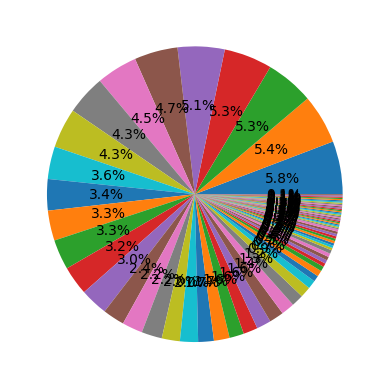

In [64]:
data_y = df['Y'].value_counts()
print(data_y)
plt.pie(data_y, autopct='%1.1f%%')

plt.show()

count    759.000000
mean      23.627141
std       15.081550
min        0.000000
25%       16.000000
50%       21.000000
75%       27.000000
max      176.000000
Name: Y, dtype: float64
[ nan   0.  17.   8.  14.   3.  19.  28.  27.  10.  12.  34.  30.  29.
  26.  13.  15.  40.  18.  31.  23.  36.  32.  42.  39.  35.  37.  54.
  44.  49.  52.  33.  45.  43.  64.  46.  41.  38.  20.  22.  16.  24.
  21. 123.  25.  11.   5.   6.   7.  98.   9.   2. 176.  53.   4.  61.
  59.  68.  47.  55.  50.  72.  91.  82.  77.  74.  63.  73.  80.  57.
  75. 104. 105. 133.  90.  83.  51.]

Mean rate: 23.627140974967062

Median rate: 21.0


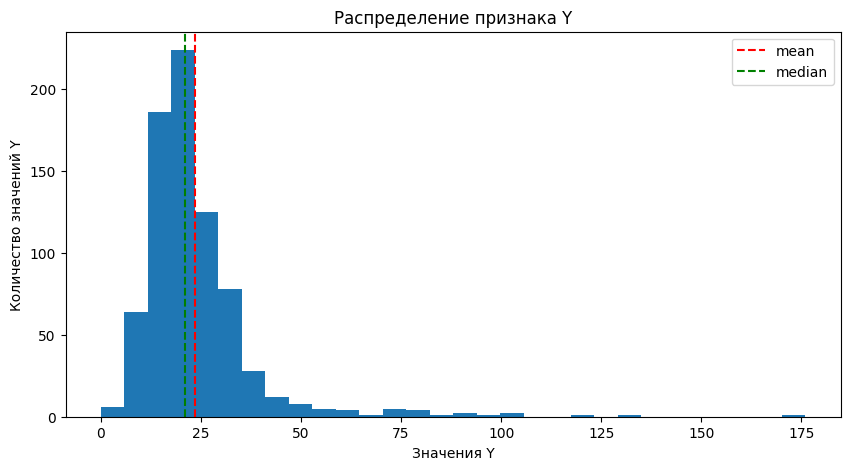

In [65]:

print(df['Y'].describe())
print(df['Y'].unique())
# Визуализация распределения
plt.figure(figsize=(10, 5))
plt.hist(df['Y'], bins=30)
plt.title('Распределение признака Y')
plt.xlabel('Значения Y')
plt.ylabel('Количество значений Y')
mean_Y = df['Y'].mean()
median_Y = df['Y'].median()
plt.axvline(x=mean_Y , color='r', linestyle='--', label='mean')
plt.axvline(x=median_Y, color='g', linestyle='--', label='median')
print(f'\nMean rate: {mean_Y}')
print(f'\nMedian rate: {median_Y}')
plt.legend()
plt.show()

### Анализ остальных признаков

TV
0        699
10258      1
9984       1
12512      1
10098      1
        ... 
14987      1
11623      1
18609      1
15449      1
26310      1
Name: count, Length: 64, dtype: int64


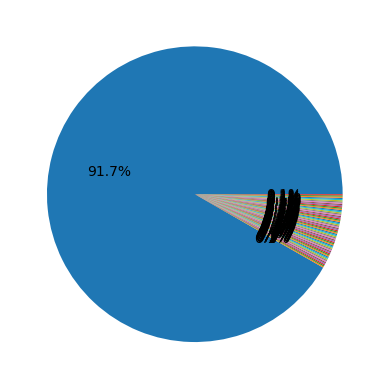

In [66]:
data_tv = df['TV'].value_counts()
print(data_tv)
plt.pie(data_tv, autopct='%1.1f%%')

plt.show()

In [67]:
columns = df.columns
columns[1:]

Index(['Y', 'TV', 'OOH', 'Seasonal_Sales', 'Usd_rate'], dtype='object')

In [68]:
'''for column in columns[2:]:
  data = df[column].value_counts()
  print(data)
  plt.pie(data, autopct='%1.1f%%')
  plt.title(f'Распределение признака {column}')
  plt.show()

  print(df[column].describe())
  print(df[column].unique())
  print(df[column].value_counts)
  # Визуализация распределения
  plt.figure(figsize=(10, 5))
  plt.hist(df[column], bins=30)
  plt.title(f'Распределение признака {column}')
  plt.xlabel(f'Значения {column}')
  plt.ylabel(f'Количество значений {column}')

  mean_attribute = df[column].mean()
  median_attribute = df[column].median()
  plt.axvline(x=mean_Y , color='r', linestyle='--', label='mean')
  plt.axvline(x=median_Y, color='g', linestyle='--', label='median')
  print(f'\nMean rate: {mean_attribute}')
  print(f'\nMedian rate: {median_attribute}')
  #plt.legend()
  plt.show()'''

"for column in columns[2:]:\n  data = df[column].value_counts()\n  print(data)\n  plt.pie(data, autopct='%1.1f%%')\n  plt.title(f'Распределение признака {column}')\n  plt.show()\n\n  print(df[column].describe())\n  print(df[column].unique())\n  print(df[column].value_counts)\n  # Визуализация распределения\n  plt.figure(figsize=(10, 5))\n  plt.hist(df[column], bins=30)\n  plt.title(f'Распределение признака {column}')\n  plt.xlabel(f'Значения {column}')\n  plt.ylabel(f'Количество значений {column}')\n\n  mean_attribute = df[column].mean()\n  median_attribute = df[column].median()\n  plt.axvline(x=mean_Y , color='r', linestyle='--', label='mean')\n  plt.axvline(x=median_Y, color='g', linestyle='--', label='median')\n  print(f'\nMean rate: {mean_attribute}')\n  print(f'\nMedian rate: {median_attribute}')\n  #plt.legend()\n  plt.show()"

### Распределения переменных

Построим гистограммы для числовых переменных:


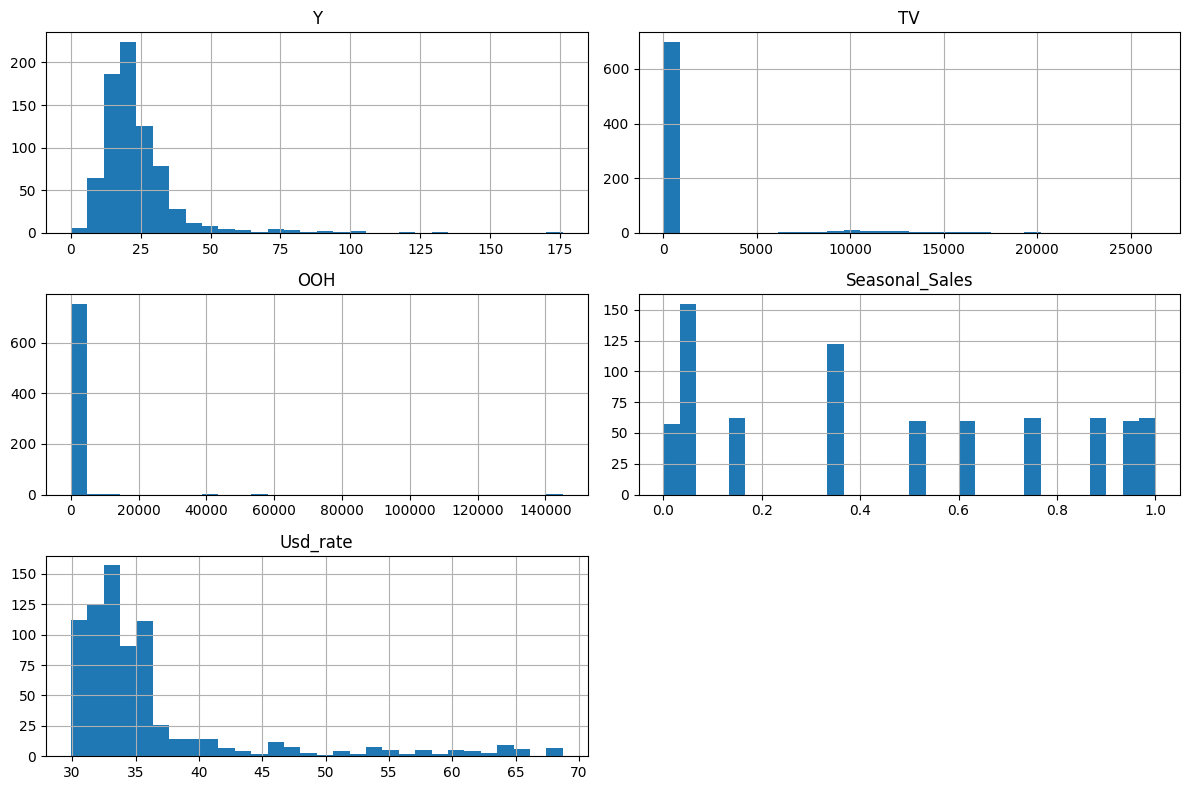

In [69]:
import seaborn as sns

numeric_cols = ['Y', 'TV', 'OOH', 'Seasonal_Sales', 'Usd_rate']
df[numeric_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()